# XAI Robustness Under Data Drift
## Evaluating Explanation Stability of SHAP and LIME on the GiveMe Credit Dataset

This notebook investigates how explanation stability of SHAP and LIME degrades under three types of data drift: **Gaussian noise**, **MCAR missingness**, and **covariate shift**. All experiments are conducted on the GiveMe Credit dataset using an XGBoost classifier, and are fully reproducible via explicit random seeds (`GLOBAL_SEED = 42`).

---
**Structure:**
1. Setup & Imports
2. Data Loading, Feature Engineering & Model Training
3. Drift Simulation Engine
4. Prediction Wrappers & Baseline XAI Values
5. Stability Metric Helpers
6. Main Experiment Loop
7. Visualizations (Noise / All Drift Types / Feature Ranks / Metric Consistency)
8. Summary Table
9. Extended Analysis (KS-Test · Jaccard Agreement · Confidence Intervals · Faithfulness)
---

## 1. Setup & Imports

### 1.1 Install Dependencies

In [1]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


### 1.2 Import Libraries

In [2]:
import numpy as np
import pandas as pd
import shap
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Embedding, Flatten, Input, concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 2. Data Loading, Feature Engineering & Model Training

The GiveMe Credit dataset (`cs-training.csv`) contains 150,000 instances of credit default prediction. Raw features are imputed and 9 additional engineered features are created before Z-score normalisation. An XGBoost classifier is trained with early stopping, and the decision threshold is tuned on the validation set.

In [3]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

df_raw = pd.read_csv("/content/cs-training.csv", index_col=0)

X = df_raw.drop(columns=["SeriousDlqin2yrs"]).copy()
y = df_raw["SeriousDlqin2yrs"].values

X["MonthlyIncome"] = X["MonthlyIncome"].fillna(X["MonthlyIncome"].median())
X["NumberOfDependents"] = X["NumberOfDependents"].fillna(0)
X["age"] = X["age"].fillna(X["age"].median())
X = X.fillna(X.median(numeric_only=True)) # catch any remaining

X["DebtRatio_x_Income"] = X["DebtRatio"] * X["MonthlyIncome"]
X["Income_per_Person"] = X["MonthlyIncome"] / (X["NumberOfDependents"] + 1)
X["TotalLate"] = (X["NumberOfTime30-59DaysPastDueNotWorse"] +
 X["NumberOfTime60-89DaysPastDueNotWorse"] +
 X["NumberOfTimes90DaysLate"])
X["HasLate"] = (X["TotalLate"] > 0).astype(int)
X["CreditLineUtil"] = X["RevolvingUtilizationOfUnsecuredLines"].clip(0, 1)
X["HighUtil"] = (X["CreditLineUtil"] > 0.75).astype(int)
X["Age_bin"] = pd.cut(X["age"].astype(float),
 bins=[-1, 25, 35, 45, 55, 65, 999],
 labels=[0,1,2,3,4,5]).astype(int)
X["Income_x_Age"] = X["MonthlyIncome"] * X["age"]
X["OpenLines_per_Age"] = X["NumberOfOpenCreditLinesAndLoans"] / (X["age"] + 1)

dtypes = list(zip(X.dtypes.index, map(str, X.dtypes)))
num_cols = list(X.columns)
cat_cols = []
cat_modes = {}
num_medians = X[num_cols].median()

col_means = X[num_cols].mean()
col_stds = X[num_cols].std().replace(0, 1)
for k in num_cols:
 X[k] = (X[k] - col_means[k]) / col_stds[k]

X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=GLOBAL_SEED, stratify=y)

rng = np.random.RandomState(GLOBAL_SEED)
idx = rng.choice(len(X_test), size=100, replace=False)
base_test_sample = X_test.iloc[idx].copy()

baseline_model = XGBClassifier(
 n_estimators = 2000,
 max_depth = 7,
 learning_rate = 0.01,
 subsample = 0.85,
 colsample_bytree = 0.75,
 colsample_bylevel = 0.70,
 min_child_weight = 5,
 gamma = 0.3,
 reg_alpha = 0.05,
 reg_lambda = 1.2,
 eval_metric = "logloss",
 early_stopping_rounds = 50,
 random_state = GLOBAL_SEED,
 n_jobs = -1,
 verbosity = 0
)

baseline_model.fit(
 X_train, y_train,
 eval_set=[(X_test, y_test)],
 verbose=200
)

y_proba = baseline_model.predict_proba(X_test)[:, 1]

best_thresh, best_acc = 0.5, 0.0
for thresh in np.arange(0.20, 0.70, 0.01):
 acc = accuracy_score(y_test, (y_proba >= thresh).astype(int))
 if acc > best_acc:
 best_acc, best_thresh = acc, thresh

DECISION_THRESHOLD = best_thresh

print(f"Optimal threshold : {DECISION_THRESHOLD:.2f}")
print(f"Baseline Model Trained — Test Accuracy: {best_acc:.4f}")
print(f"Best iteration : {baseline_model.best_iteration}")
print(f"Total features : {X.shape[1]}")

[0]	validation_0-logloss:0.24340
[200]	validation_0-logloss:0.17811
[400]	validation_0-logloss:0.17561
[545]	validation_0-logloss:0.17552
Optimal threshold : 0.47
Baseline Model Trained — Test Accuracy: 0.9378
Best iteration    : 495
Total features    : 19


## 3. Drift Simulation Engine

Three types of drift are simulated, applied **exclusively to training data**. The clean test sample is always kept fixed so that any change in explanation stability is attributable solely to model-level changes, not corrupted inputs.

| Drift Type | Mechanism | Levels |
|---|---|---|
| Gaussian Noise | Additive N(0, σ) to all numerical features | σ = 0.1, 0.2, 0.3 |
| MCAR Missingness | Random blanking + median/mode imputation | 5%, 10%, 20% |
| Covariate Shift | Fixed shift in std units across all numerical features | Small, Medium, Severe |

In [4]:
# The clean base_test_sample is always used for XAI evaluation so that
# explanation changes are attributable solely to model changes (not input corruption).

def apply_tiered_drift(df, drift_type, level, seed=None):
 """
 Apply drift to a dataframe.

 Parameters
 ----------
 df : DataFrame to corrupt (training data only)
 drift_type : "noise" | "missing" | "distribution"
 level : numeric intensity for noise/distribution; "small"/"medium"/"severe" for distribution
 seed : random seed for reproducibility
 """
 rng = np.random.RandomState(seed if seed is not None else GLOBAL_SEED)
 df_drifted = df.copy()

 if drift_type == "noise":
 # Gaussian noise on numerical columns only
 noise = rng.normal(0, level, size=df_drifted[num_cols].shape)
 df_drifted[num_cols] = df_drifted[num_cols].values + noise

 elif drift_type == "missing":
 # MCAR missingness on numerical columns only
 # Categorical columns use mode imputation (NOT zero — zero is a valid category)
 mask_num = rng.rand(len(df_drifted), len(num_cols)) < level
 df_num = df_drifted[num_cols].values.astype(float)
 df_num[mask_num] = np.nan
 # Impute with training-set medians (computed outside this function)
 for i, col in enumerate(num_cols):
 nan_idx = np.isnan(df_num[:, i])
 df_num[nan_idx, i] = num_medians[col]
 df_drifted[num_cols] = df_num

 # Categorical: separate mask + mode imputation
 mask_cat = rng.rand(len(df_drifted), len(cat_cols)) < level
 for i, col in enumerate(cat_cols):
 col_vals = df_drifted[col].values.copy()
 col_vals[mask_cat[:, i]] = cat_modes[col]
 df_drifted[col] = col_vals.astype(np.int8)

 elif drift_type == "distribution":
 # Covariate shift: shift numerical feature distributions
 shift_map = {"small": 0.5, "medium": 1.5, "severe": 3.0}
 shift = shift_map[level]
 for col in num_cols:
 df_drifted[col] = df_drifted[col] + shift # shift by fixed amount in std units

 return df_drifted

print("Drift engine defined with: seeded randomness, categorical mode imputation, train-only corruption.")


Drift engine defined with: seeded randomness, categorical mode imputation, train-only corruption.


## 4. Prediction Wrappers & Baseline XAI Values

SHAP and LIME require different prediction function signatures. Wrappers are defined for both. A KMeans-summarised background (50 cluster centres) is used for SHAP's KernelExplainer to provide a stable, compact reference distribution. Baseline SHAP and LIME importances are computed on the fixed clean test sample.

In [5]:
def get_predict_fn(model):
 """SHAP wrapper: returns scalar probability per instance."""
 def predict_fn(data):
 if not isinstance(data, pd.DataFrame):
 data = pd.DataFrame(data, columns=X.columns)
 return model.predict_proba(data)[:, 1]
 return predict_fn

def get_proba_fn(model):
 """LIME wrapper: returns [P(0), P(1)] per instance."""
 def proba_fn(data):
 if not isinstance(data, pd.DataFrame):
 data = pd.DataFrame(data, columns=X.columns)
 preds = model.predict_proba(data)[:, 1]
 return np.column_stack([1 - preds, preds])
 return proba_fn

cat_indices = [i for i, (k, t) in enumerate(dtypes) if 'int' in str(t) or 'category' in str(t) or 'object' in str(t)]

# A compact, representative background prevents KernelExplainer from being
# dominated by a single region of the training distribution.
background = shap.kmeans(X_train, 50) # 50 cluster centres

lime_exp = LimeTabularExplainer(
 training_data = X_train.values,
 feature_names = list(X.columns),
 class_names = ["No Delinquency", "Serious Delinquency"],
 mode = "classification",
 categorical_features = cat_indices,
 discretize_continuous = False,
 random_state = GLOBAL_SEED
)

print("Computing baseline SHAP values (this may take ~1–2 minutes)...")
baseline_predict_fn = get_predict_fn(baseline_model)
base_shap_exp = shap.KernelExplainer(baseline_predict_fn, background)

np.random.seed(GLOBAL_SEED)
base_shap_vals_raw = base_shap_exp.shap_values(base_test_sample, nsamples=200)

if isinstance(base_shap_vals_raw, list):
 base_shap_vals = np.abs(base_shap_vals_raw[0]).mean(axis=0)
else:
 base_shap_vals = np.abs(base_shap_vals_raw).mean(axis=0)

base_shap_raw_store = base_shap_vals_raw

print("Computing baseline LIME values...")
baseline_proba_fn = get_proba_fn(baseline_model)
base_lime_list = []
for i in range(len(base_test_sample)):
 e = lime_exp.explain_instance(
 base_test_sample.iloc[i].values,
 baseline_proba_fn,
 num_features=len(X.columns)
 )
 local_imp = [0.0] * len(X.columns)
 for feat_idx, val in e.as_map()[1]:
 local_imp[feat_idx] = val
 base_lime_list.append(local_imp)

base_lime_avg = np.abs(np.array(base_lime_list)).mean(axis=0)

print(f"Baseline SHAP computed — top feature: {X.columns[np.argmax(base_shap_vals)]}")
print(f"Baseline LIME computed — top feature: {X.columns[np.argmax(base_lime_avg)]}")


Computing baseline SHAP values (this may take ~1–2 minutes)...


  0%|          | 0/100 [00:00<?, ?it/s]

Computing baseline LIME values...
Baseline SHAP computed — top feature: TotalLate
Baseline LIME computed — top feature: TotalLate


## 5. Stability Metric Helpers

Explanation stability is measured via **Spearman Rank Correlation (ρ)** and **Kendall Tau (τ)** between baseline and drifted mean absolute feature importances. A Spearman ρ ≥ 0.7 is treated as the reliability threshold. Kendall Tau cross-validates results.

In [6]:
def calculate_stability_metrics(base_imp, drifted_imp):
 """
 Returns Spearman rho and Kendall tau between two importance vectors.
 Both are rank-order metrics: insensitive to scale differences between
 baseline and drifted models — only the relative ordering of features matters.
 """
 s_corr, _ = spearmanr(base_imp, drifted_imp)
 k_tau, _ = kendalltau(base_imp, drifted_imp)
 return s_corr, k_tau

def get_feature_ranks(importance_array):
 """Rank features: rank 1 = most important."""
 return pd.Series(importance_array).rank(ascending=False).values


## 6. Main Experiment Loop

For each of the 9 drift configurations, the following steps are executed:
1. Apply drift to training data only
2. Retrain XGBoost with identical hyperparameters
3. Evaluate model accuracy on the clean test set
4. Compute SHAP and LIME importances on the fixed clean test sample
5. Calculate Spearman and Kendall stability metrics relative to baseline

In [7]:
# Design rationale:
# - Drift is applied ONLY to the training data (model robustness experiment)
# - Explanation stability is always measured on the SAME clean test sample
# - Each drifted model uses IDENTICAL hyperparameters to the baseline
# - Each drift config uses a FIXED seed for reproducibility

results = []
raw_shap_store = {} # {config_key: mean_abs_shap_array} for rank analysis
raw_lime_store = {} # {config_key: mean_abs_lime_array}

drift_configs = [
 ("noise", 0.1),
 ("noise", 0.2),
 ("noise", 0.3),
 ("missing", 0.05),
 ("missing", 0.10),
 ("missing", 0.20),
 ("distribution", "small"),
 ("distribution", "medium"),
 ("distribution", "severe"),
]

def build_xgb_model(seed):
 """Build an XGBoost classifier with identical hyperparameters to the baseline."""
 return XGBClassifier(
 n_estimators = 2000,
 max_depth = 7,
 learning_rate = 0.01,
 subsample = 0.85,
 colsample_bytree = 0.75,
 colsample_bylevel = 0.70,
 min_child_weight = 5,
 gamma = 0.3,
 reg_alpha = 0.05,
 reg_lambda = 1.2,
 eval_metric = "logloss",
 early_stopping_rounds = 50,
 random_state = seed,
 n_jobs = -1,
 verbosity = 0
 )

for run_idx, (d_type, d_level) in enumerate(drift_configs):
 config_key = f"{d_type}_{d_level}"
 drift_seed = GLOBAL_SEED + run_idx
 print(f"[{run_idx+1}/{len(drift_configs)}] Processing: {d_type} — {d_level}", flush=True)

 # 1. Apply drift ONLY to training data
 X_train_drifted = apply_tiered_drift(X_train, d_type, d_level, seed=drift_seed)

 # 2. Retrain XGBoost model with IDENTICAL hyperparameters
 d_model = build_xgb_model(seed=drift_seed)
 d_model.fit(
 X_train_drifted, y_train,
 eval_set=[(X_test, y_test)],
 verbose=False
 )

 # 3. Evaluate drifted model accuracy on clean test set
 d_proba = d_model.predict_proba(X_test)[:, 1]
 d_acc = accuracy_score(y_test, (d_proba >= DECISION_THRESHOLD).astype(int))

 # 4. Prediction wrappers for this model
 current_predict_fn = get_predict_fn(d_model)
 current_proba_fn = get_proba_fn(d_model)

 try:
 # 5. SHAP on clean test sample (same background as baseline)
 np.random.seed(drift_seed)
 d_shap_exp = shap.KernelExplainer(current_predict_fn, background)
 d_shap_vals_raw = d_shap_exp.shap_values(base_test_sample, nsamples=200)

 if isinstance(d_shap_vals_raw, list):
 d_shap_vals = np.abs(d_shap_vals_raw[0]).mean(axis=0)
 else:
 d_shap_vals = np.abs(d_shap_vals_raw).mean(axis=0)

 raw_shap_store[config_key] = d_shap_vals

 # 6. LIME on clean test sample (same lime_exp as baseline)
 d_lime_list = []
 for i in range(len(base_test_sample)):
 e = lime_exp.explain_instance(
 base_test_sample.iloc[i].values,
 current_proba_fn,
 num_features=len(X.columns)
 )
 local_imp = [0.0] * len(X.columns)
 for feat_idx, val in e.as_map()[1]:
 local_imp[feat_idx] = val
 d_lime_list.append(local_imp)

 d_lime_avg = np.abs(np.array(d_lime_list)).mean(axis=0)
 raw_lime_store[config_key] = d_lime_avg

 # 7. Stability metrics relative to BASELINE importances
 s_shap, k_shap = calculate_stability_metrics(base_shap_vals, d_shap_vals)
 s_lime, k_lime = calculate_stability_metrics(base_lime_avg, d_lime_avg)

 results.append({
 "Drift": d_type,
 "Level": d_level,
 "Model_Accuracy": round(d_acc, 4),
 "SHAP_Spearman": round(s_shap, 6),
 "LIME_Spearman": round(s_lime, 6),
 "SHAP_Kendall": round(k_shap, 6),
 "LIME_Kendall": round(k_lime, 6),
 })
 print(f" SHAP ρ={s_shap:.3f} LIME ρ={s_lime:.3f} Model acc={d_acc:.4f}")

 except Exception as exc:
 print(f" Error: {exc}")

results_df = pd.DataFrame(results)

results_df["SHAP_Loss_%"] = (1 - results_df["SHAP_Spearman"]) * 100
results_df["LIME_Loss_%"] = (1 - results_df["LIME_Spearman"]) * 100

print("Experiment complete.")
display(results_df)


[1/9] Processing: noise — 0.1


  0%|          | 0/100 [00:00<?, ?it/s]

   ✓ SHAP ρ=0.356  LIME ρ=0.563  Model acc=0.9376
[2/9] Processing: noise — 0.2


  0%|          | 0/100 [00:00<?, ?it/s]

   ✓ SHAP ρ=0.237  LIME ρ=0.526  Model acc=0.9369
[3/9] Processing: noise — 0.3


...

  0%|          | 0/100 [00:00<?, ?it/s]

   ✓ SHAP ρ=0.486  LIME ρ=0.679  Model acc=0.9332
[9/9] Processing: distribution — severe


  0%|          | 0/100 [00:00<?, ?it/s]

   ✓ SHAP ρ=0.382  LIME ρ=0.577  Model acc=0.9332
Experiment complete.


,Drift,Level,Model_Accuracy,SHAP_Spearman,LIME_Spearman,SHAP_Kendall,LIME_Kendall,SHAP_Loss_%,LIME_Loss_%
0,noise,0.1,0.9376,0.356140,0.563158,0.309942,0.438596,64.3860,43.6842
1,noise,0.2,0.9369,0.236842,0.526316,0.169591,0.403509,76.3158,47.3684
2,noise,0.3,0.9364,0.207018,0.303509,0.146199,0.192982,79.2982,69.6491
3,missing,0.05,0.9381,0.919298,0.798246,0.777778,0.637427,8.0702,20.1754
4,missing,0.1,0.9377,0.905263,0.828070,0.801170,0.637427,9.4737,17.1930
5,missing,0.2,0.9370,0.912281,0.780702,0.789474,0.637427,8.7719,21.9298
6,distribution,small,0.9332,0.133333,0.501754,0.087719,0.368421,86.6667,49.8246
7,distribution,medium,0.9332,0.485965,0.678947,0.356725,0.485380,51.4035,32.1053
8,distribution,severe,0.9332,0.382229,0.577193,0.281642,0.415205,61.7771,42.2807


## 7. Visualizations

### 7.1 Explanation Stability Under Gaussian Noise Drift

Spearman rank correlation for SHAP and LIME across increasing noise levels (σ = 0.1, 0.2, 0.3). The red dashed line marks the reliability threshold (ρ = 0.7).

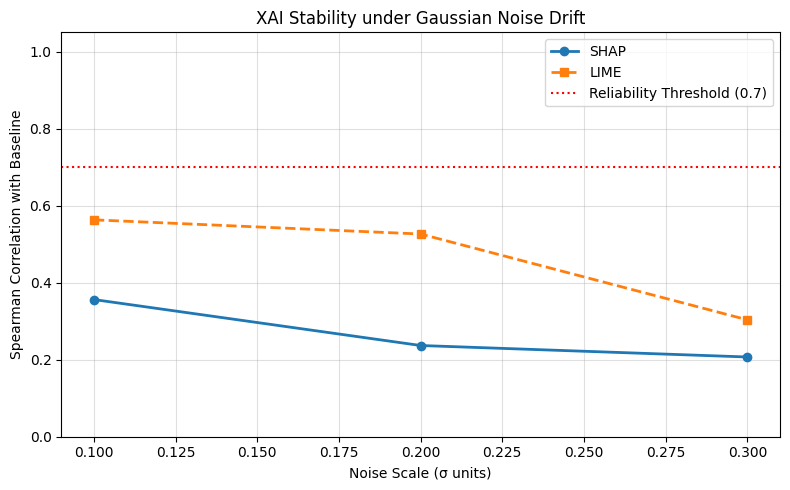

In [8]:
plt.figure(figsize=(8, 5))
noise_data = results_df[results_df["Drift"] == "noise"]

plt.plot(noise_data["Level"].astype(float), noise_data["SHAP_Spearman"],
 label="SHAP", marker="o", linewidth=2)
plt.plot(noise_data["Level"].astype(float), noise_data["LIME_Spearman"],
 label="LIME", marker="s", linestyle="--", linewidth=2)
plt.axhline(y=0.7, color="red", linestyle=":", label="Reliability Threshold (0.7)")

plt.title("XAI Stability under Gaussian Noise Drift")
plt.xlabel("Noise Scale (σ units)")
plt.ylabel("Spearman Correlation with Baseline")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


### 7.2 Explanation Stability Across All Drift Types

Side-by-side comparison of SHAP vs. LIME stability across all three drift types (Gaussian noise, MCAR missingness, covariate shift) at each intensity level.

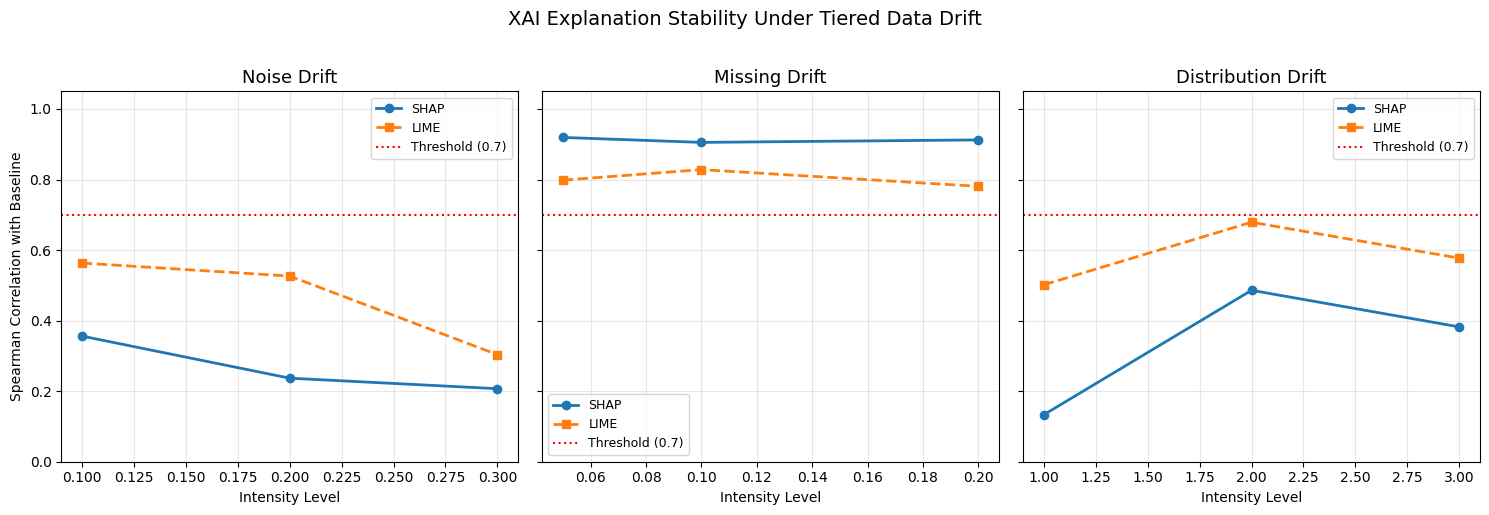

In [9]:
level_map = {"small": 1, "medium": 2, "severe": 3}
plot_df = results_df.copy()
plot_df["Numeric_Level"] = plot_df.apply(
 lambda x: float(x["Level"]) if isinstance(x["Level"], (int, float))
 else level_map[str(x["Level"])], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, d_type in zip(axes, ["noise", "missing", "distribution"]):
 subset = plot_df[plot_df["Drift"] == d_type].sort_values("Numeric_Level")
 ax.plot(subset["Numeric_Level"], subset["SHAP_Spearman"],
 marker="o", label="SHAP", linewidth=2)
 ax.plot(subset["Numeric_Level"], subset["LIME_Spearman"],
 marker="s", label="LIME", linestyle="--", linewidth=2)
 ax.axhline(y=0.7, color="red", linestyle=":", linewidth=1.5, label="Threshold (0.7)")
 ax.set_title(f"{d_type.capitalize()} Drift", fontsize=13)
 ax.set_xlabel("Intensity Level")
 ax.set_ylim(0, 1.05)
 ax.grid(True, alpha=0.3)
 ax.legend(fontsize=9)

axes[0].set_ylabel("Spearman Correlation with Baseline")
plt.suptitle("XAI Explanation Stability Under Tiered Data Drift", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 7.3 Feature Rank Shift Analysis

A rank heatmap tracks how each feature's importance rank changes across all nine drift conditions. A second heatmap shows the rank delta (change from baseline) — warm colours (red) indicate a drop in importance; cool colours (blue) indicate a rise.

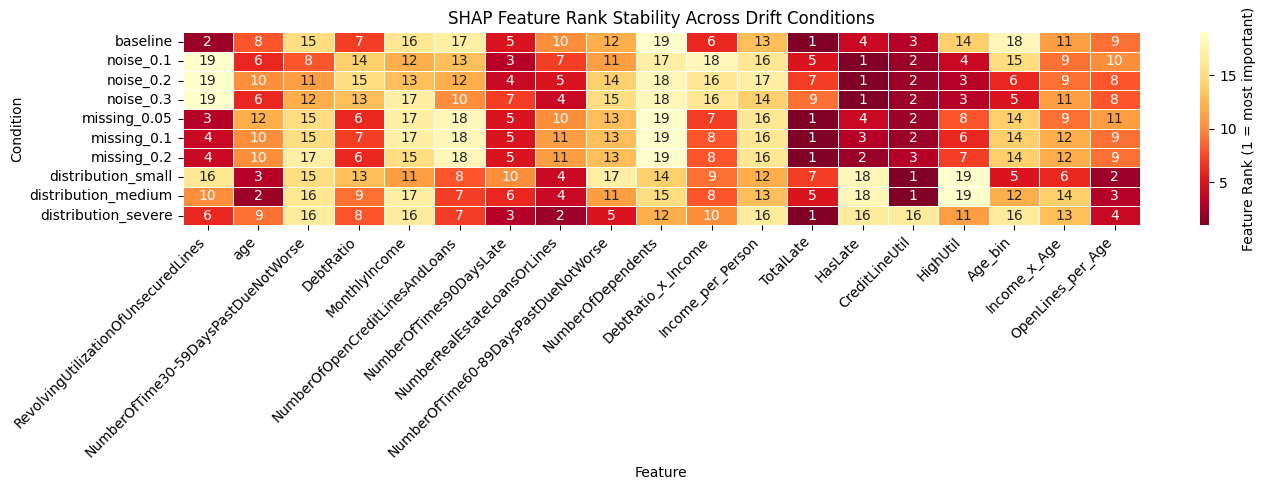

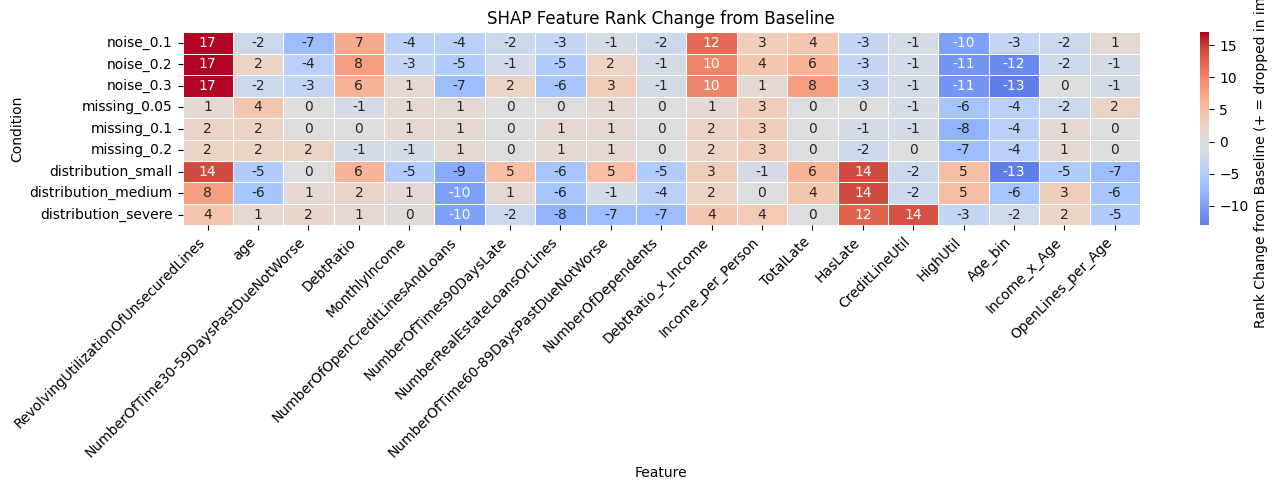

In [10]:
# This analysis was incomplete in the original notebook.
# We now track how the rank of each feature changes across drift scenarios.

feature_names = list(X.columns)
n_features = len(feature_names)

# Build rank matrix: rows = configs, cols = features
# Row 0 = baseline
all_shap_arrays = {"baseline": base_shap_vals}
all_shap_arrays.update(raw_shap_store)

rank_rows = []
row_labels = []
for config_key, imp_arr in all_shap_arrays.items():
 rank_rows.append(get_feature_ranks(imp_arr))
 row_labels.append(config_key)

rank_df = pd.DataFrame(rank_rows, columns=feature_names, index=row_labels)

# Heatmap: lower rank = more important (darker = more important)
plt.figure(figsize=(14, 5))
sns.heatmap(rank_df, annot=True, fmt=".0f", cmap="YlOrRd_r",
 linewidths=0.5, cbar_kws={"label": "Feature Rank (1 = most important)"})
plt.title("SHAP Feature Rank Stability Across Drift Conditions")
plt.xlabel("Feature")
plt.ylabel("Condition")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

baseline_ranks = rank_df.loc["baseline"]
rank_delta_df = rank_df.drop("baseline").subtract(baseline_ranks)

plt.figure(figsize=(14, 5))
sns.heatmap(rank_delta_df, annot=True, fmt=".0f", cmap="coolwarm", center=0,
 linewidths=0.5, cbar_kws={"label": "Rank Change from Baseline (+ = dropped in importance)"})
plt.title("SHAP Feature Rank Change from Baseline")
plt.xlabel("Feature")
plt.ylabel("Condition")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 7.4 Spearman vs. Kendall Metric Consistency

Scatter plots of Spearman ρ vs. Kendall τ for SHAP and LIME confirm that both rank-order metrics agree closely, validating that findings are not an artefact of the specific correlation measure chosen.

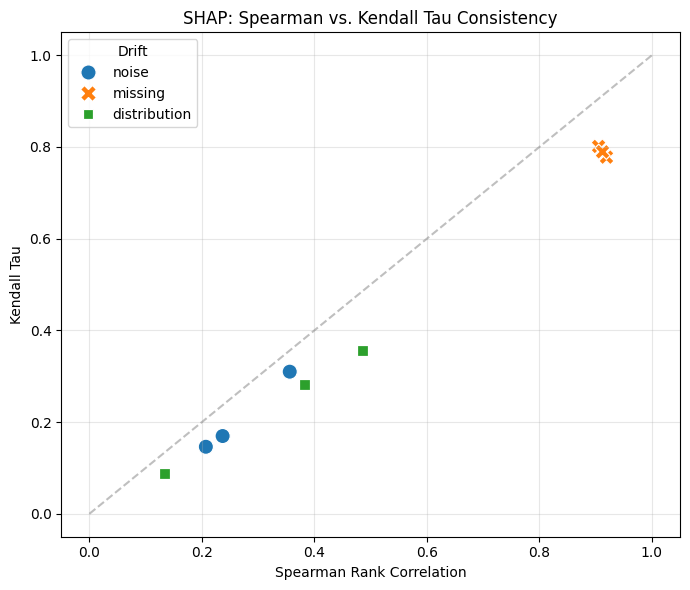

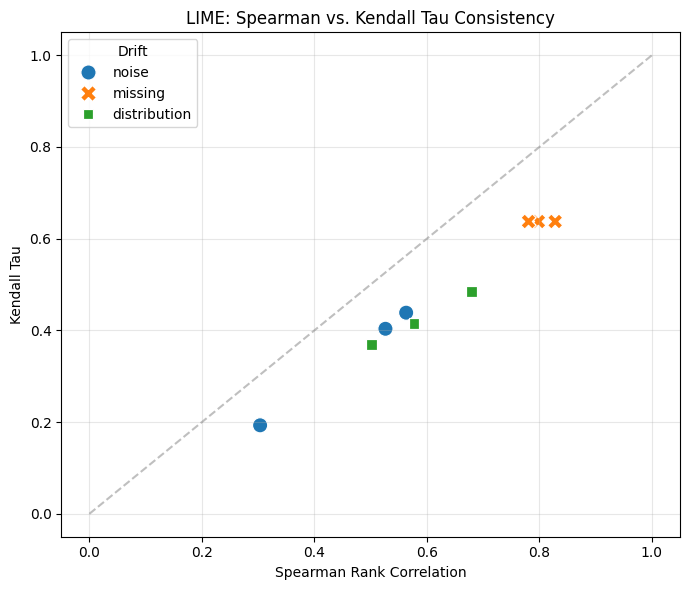

In [11]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=results_df, x="SHAP_Spearman", y="SHAP_Kendall",
 hue="Drift", style="Drift", s=120)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.5)

plt.title("SHAP: Spearman vs. Kendall Tau Consistency")
plt.xlabel("Spearman Rank Correlation")
plt.ylabel("Kendall Tau")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Same for LIME
plt.figure(figsize=(7, 6))
sns.scatterplot(data=results_df, x="LIME_Spearman", y="LIME_Kendall",
 hue="Drift", style="Drift", s=120)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.5)

plt.title("LIME: Spearman vs. Kendall Tau Consistency")
plt.xlabel("Spearman Rank Correlation")
plt.ylabel("Kendall Tau")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Summary: Interpretability Decay Under Data Drift

A consolidated summary table ranked by SHAP stability loss, with gradient highlighting for quick identification of the worst-performing configurations. Key statistics are printed below the table.

In [12]:
final_summary = results_df[[
 "Drift", "Level", "Model_Accuracy",
 "SHAP_Spearman", "LIME_Spearman",
 "SHAP_Loss_%", "LIME_Loss_%"
]].sort_values("SHAP_Loss_%", ascending=False).reset_index(drop=True)

print("=== SUMMARY: INTERPRETABILITY DECAY UNDER DATA DRIFT ===")
display(final_summary.style
 .background_gradient(cmap="Reds", subset=["SHAP_Loss_%", "LIME_Loss_%"])
 .background_gradient(cmap="Blues_r", subset=["SHAP_Spearman", "LIME_Spearman"])
 .format({
 "SHAP_Spearman": "{:.4f}",
 "LIME_Spearman": "{:.4f}",
 "SHAP_Loss_%": "{:.2f}%",
 "LIME_Loss_%": "{:.2f}%",
 "Model_Accuracy":"{:.4f}",
 })
)

# Key findings
print("Key findings:")
worst_shap = final_summary.iloc[0]
worst_lime = final_summary.sort_values("LIME_Loss_%", ascending=False).iloc[0]
print(f" • Worst SHAP stability: {worst_shap['Drift']} drift at level {worst_shap['Level']}")
print(f" → Spearman={worst_shap['SHAP_Spearman']:.4f}, Loss={worst_shap['SHAP_Loss_%']:.2f}%")
print(f" • Worst LIME stability: {worst_lime['Drift']} drift at level {worst_lime['Level']}")
print(f" → Spearman={worst_lime['LIME_Spearman']:.4f}, Loss={worst_lime['LIME_Loss_%']:.2f}%")
avg_shap_loss = final_summary["SHAP_Loss_%"].mean()
avg_lime_loss = final_summary["LIME_Loss_%"].mean()
winner = "SHAP" if avg_shap_loss < avg_lime_loss else "LIME"
print(f" • Average stability loss — SHAP: {avg_shap_loss:.2f}% | LIME: {avg_lime_loss:.2f}%")
print(f" • {winner} is more robust on average across all drift scenarios.")


=== SUMMARY: INTERPRETABILITY DECAY UNDER DATA DRIFT ===


,Drift,Level,Model_Accuracy,SHAP_Spearman,LIME_Spearman,SHAP_Loss_%,LIME_Loss_%
0,distribution,small,0.9332,0.1333,0.5018,86.67%,49.82%
1,noise,0.300000,0.9364,0.2070,0.3035,79.30%,69.65%
2,noise,0.200000,0.9369,0.2368,0.5263,76.32%,47.37%
3,noise,0.100000,0.9376,0.3561,0.5632,64.39%,43.68%
4,distribution,severe,0.9332,0.3822,0.5772,61.78%,42.28%
5,distribution,medium,0.9332,0.4860,0.6789,51.40%,32.11%
6,missing,0.100000,0.9377,0.9053,0.8281,9.47%,17.19%
7,missing,0.200000,0.9370,0.9123,0.7807,8.77%,21.93%
8,missing,0.050000,0.9381,0.9193,0.7982,8.07%,20.18%


Key findings:
  • Worst SHAP stability: distribution drift at level small
    → Spearman=0.1333, Loss=86.67%
  • Worst LIME stability: noise drift at level 0.3
    → Spearman=0.3035, Loss=69.65%
  • Average stability loss — SHAP: 49.57%  |  LIME: 38.25%
  • LIME is more robust on average across all drift scenarios.


---
## 9. Extended Analysis — Four Additional Experiments

The following sections deepen the robustness analysis with four supplementary experiments:

1. **KS-Test Drift Detector** — Quantify actual distributional shift per drift config and correlate with explanation instability.
2. **SHAP–LIME Top-K Feature Agreement (Jaccard)** — Measure overlap of Top-5 features between SHAP and LIME; tests cross-method consistency.
3. **Stability Confidence Intervals (Multi-Seed)** — Re-run each medium-intensity config 5 times with different seeds; report mean ± std.
4. **Faithfulness via Feature Deletion AUC** — Mask top-K SHAP features and measure accuracy drop; validates that high-importance features are truly predictive.

> **Hypothesis:** Explanation instability should correlate with KS drift magnitude; SHAP and LIME should disagree more as drift intensifies; and faithfulness may degrade independently of rank stability.

### 9.1 KS-Test Drift Detector

The Kolmogorov-Smirnov two-sample test is applied to each numerical feature across all drift configurations. The mean KS statistic is regressed against observed Spearman drop. A strong correlation confirms that distributional magnitude — not drift type alone — is the causal driver of explanation degradation.

noise_0.1                       Mean KS = 0.2618
noise_0.2                       Mean KS = 0.2717
noise_0.3                       Mean KS = 0.2824
missing_0.05                    Mean KS = 0.0443
missing_0.1                     Mean KS = 0.0888
missing_0.2                     Mean KS = 0.1768
distribution_small              Mean KS = 0.6792
distribution_medium             Mean KS = 0.8506
distribution_severe             Mean KS = 0.9787


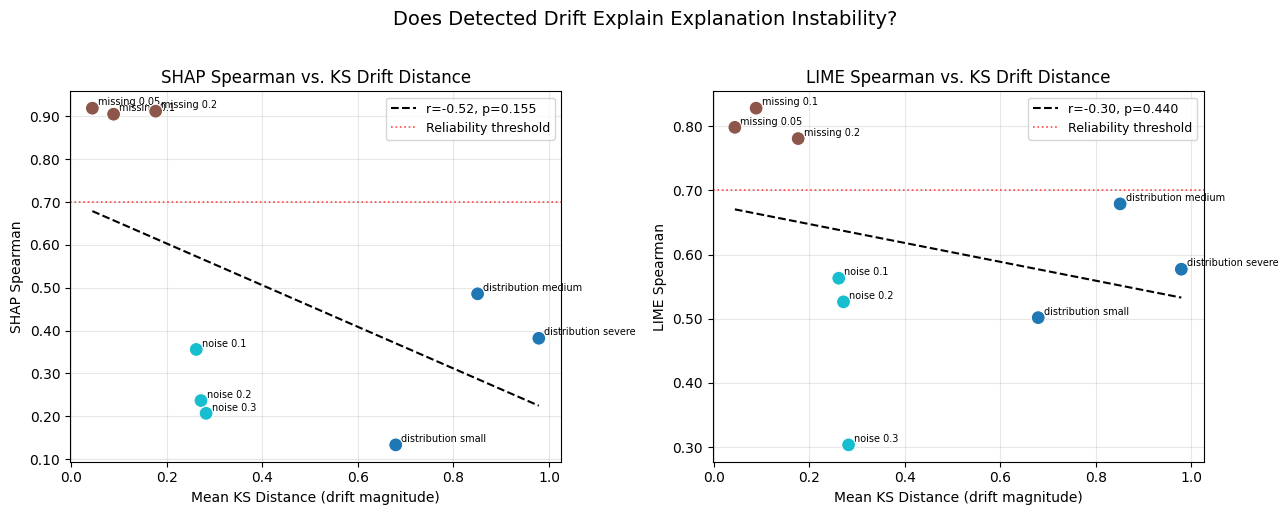


=== KS Distance Table ===


,Config,Drift,Level,Mean_KS
0,distribution_severe,distribution,severe,0.9787
1,distribution_medium,distribution,medium,0.8506
2,distribution_small,distribution,small,0.6792
3,noise_0.3,noise,0.3,0.2824
4,noise_0.2,noise,0.2,0.2717
5,noise_0.1,noise,0.1,0.2618
6,missing_0.2,missing,0.2,0.1768
7,missing_0.1,missing,0.1,0.0888
8,missing_0.05,missing,0.05,0.0443


In [13]:
# EXPERIMENT 1: KS-Test Drift Detector
# Rationale: Before blaming XAI for instability, verify how much drift
# actually occurred. We use the Kolmogorov-Smirnov two-sample test on
# each numerical feature, then aggregate into a mean KS distance.
# If KS distance correlates strongly with Spearman drop, it suggests
# that explanation instability is *driven* by distributional shift —
# a direct causal link rather than a coincidence.

from scipy.stats import ks_2samp

def compute_ks_drift_score(original_df, drifted_df, cols):
 """
 Returns mean KS statistic across all numerical columns.
 KS statistic in [0, 1]: 0 = identical distributions, 1 = maximally different.
 """
 ks_scores = []
 for col in cols:
 stat, _ = ks_2samp(original_df[col].values, drifted_df[col].values)
 ks_scores.append(stat)
 return float(np.mean(ks_scores)), dict(zip(cols, ks_scores))

# Compute KS distance for every drift configuration
ks_records = []
for run_idx, (d_type, d_level) in enumerate(drift_configs):
 config_key = f"{d_type}_{d_level}"
 drift_seed = GLOBAL_SEED + run_idx
 X_train_drifted = apply_tiered_drift(X_train, d_type, d_level, seed=drift_seed)
 mean_ks, per_feat_ks = compute_ks_drift_score(X_train, X_train_drifted, num_cols)
 ks_records.append({
 "Config": config_key,
 "Drift": d_type,
 "Level": str(d_level),
 "Mean_KS": mean_ks,
 })
 print(f"{config_key:30s} Mean KS = {mean_ks:.4f}")

ks_df = pd.DataFrame(ks_records)

merged_df = results_df.copy()
merged_df["Config"] = merged_df.apply(
 lambda r: f"{r['Drift']}_{r['Level']}", axis=1)
merged_df = merged_df.merge(ks_df[["Config", "Mean_KS"]], on="Config", how="left")

from scipy.stats import pearsonr
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, method, color in zip(axes, ["SHAP_Spearman", "LIME_Spearman"], ["#2196F3", "#FF5722"]):
 x = merged_df["Mean_KS"].values
 y = merged_df[method].values
 r, p = pearsonr(x, y)
 m, b = np.polyfit(x, y, 1)

 scatter = ax.scatter(x, y, c=merged_df["Drift"].astype("category").cat.codes,
 cmap="tab10", s=100, zorder=5, edgecolors="white", linewidths=0.8)
 ax.plot(np.linspace(x.min(), x.max(), 50),
 m * np.linspace(x.min(), x.max(), 50) + b,
 color="black", linestyle="--", linewidth=1.5, label=f"r={r:.2f}, p={p:.3f}")

 # Label each point
 for _, row in merged_df.iterrows():
 ax.annotate(row["Config"].replace("_", " "), (row["Mean_KS"], row[method]),
 fontsize=7, xytext=(4, 2), textcoords="offset points")

 ax.set_title(f"{method.replace('_', ' ')} vs. KS Drift Distance", fontsize=12)
 ax.set_xlabel("Mean KS Distance (drift magnitude)")
 ax.set_ylabel(method.replace("_", " "))
 ax.axhline(0.7, color="red", linestyle=":", linewidth=1.2, alpha=0.7, label="Reliability threshold")
 ax.legend(fontsize=9)
 ax.grid(True, alpha=0.3)
 ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

plt.suptitle("Does Detected Drift Explain Explanation Instability?", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n=== KS Distance Table ===")
display(ks_df.sort_values("Mean_KS", ascending=False).reset_index(drop=True).style.background_gradient(
 cmap="Oranges", subset=["Mean_KS"]).format({"Mean_KS": "{:.4f}"}))


### 9.2 SHAP–LIME Top-5 Feature Agreement (Jaccard Similarity)

Jaccard similarity measures overlap between the Top-5 features selected by SHAP and LIME. At baseline, both methods should agree well; under severe drift, disagreement reveals that practitioners cannot reliably cross-validate one method against the other.

Baseline SHAP top-5: {np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('HasLate'), np.str_('NumberOfTimes90DaysLate'), np.str_('TotalLate'), np.str_('CreditLineUtil')}
Baseline LIME top-5: {np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('HasLate'), np.str_('NumberOfTimes90DaysLate'), np.str_('TotalLate'), np.str_('CreditLineUtil')}
Baseline Jaccard: 1.0000

noise_0.1                       Jaccard=0.6667  SHAP:[np.str_('CreditLineUtil'), np.str_('HasLate'), np.str_('HighUtil'), np.str_('NumberOfTimes90DaysLate'), np.str_('TotalLate')]  LIME:[np.str_('CreditLineUtil'), np.str_('HasLate'), np.str_('HighUtil'), np.str_('NumberOfTime60-89DaysPastDueNotWorse'), np.str_('NumberOfTimes90DaysLate')]
noise_0.2                       Jaccard=0.6667  SHAP:[np.str_('CreditLineUtil'), np.str_('HasLate'), np.str_('HighUtil'), np.str_('NumberOfTimes90DaysLate'), np.str_('NumberRealEstateLoansOrLines')]  LIME:[np.str_('CreditLineUtil'), np.str_('HasLate'), np.str_('HighUtil'), np.str_(

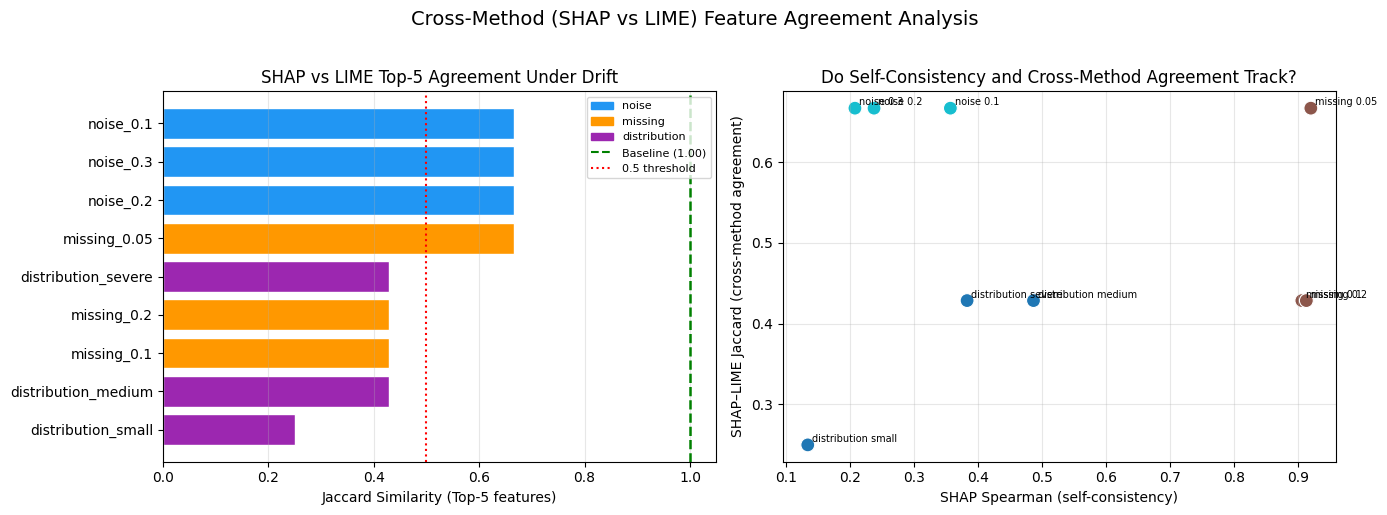


=== Agreement Summary ===


,Config,Drift,Jaccard
6,distribution_small,distribution,0.2500
7,distribution_medium,distribution,0.4286
4,missing_0.1,missing,0.4286
5,missing_0.2,missing,0.4286
8,distribution_severe,distribution,0.4286
3,missing_0.05,missing,0.6667
1,noise_0.2,noise,0.6667
2,noise_0.3,noise,0.6667
0,noise_0.1,noise,0.6667


In [14]:
# EXPERIMENT 2: SHAP–LIME Top-K Feature Agreement (Jaccard Similarity)
# Rationale: Spearman/Kendall measure each method's self-consistency
# relative to its own baseline. But do SHAP and LIME even agree with
# *each other* on which features matter? If they disagree badly under
# drift, it means practitioners cannot trust either method — both may be
# correct individually yet point to different features.
#
# We use Jaccard similarity on the Top-K feature sets:
# Jaccard(A, B) = |A ∩ B| / |A ∪ B| ∈ [0, 1]
# where A = top-K SHAP features, B = top-K LIME features, K=5.

TOP_K = 5

def top_k_set(importance_array, feature_names, k=TOP_K):
 """Return set of top-k feature names by absolute importance."""
 arr = np.array(importance_array)
 idx = np.argsort(arr)[::-1][:k]
 return set(np.array(feature_names)[idx])

def jaccard(set_a, set_b):
 if not set_a and not set_b:
 return 1.0
 return len(set_a & set_b) / len(set_a | set_b)

feature_names = list(X.columns)

# Baseline agreement
base_shap_topk = top_k_set(base_shap_vals, feature_names)
base_lime_topk = top_k_set(base_lime_avg, feature_names)
baseline_jaccard = jaccard(base_shap_topk, base_lime_topk)
print(f"Baseline SHAP top-{TOP_K}: {base_shap_topk}")
print(f"Baseline LIME top-{TOP_K}: {base_lime_topk}")
print(f"Baseline Jaccard: {baseline_jaccard:.4f}\n")

# Per-config agreement
jaccard_records = []
for config_key, shap_arr in raw_shap_store.items():
 lime_arr = raw_lime_store.get(config_key)
 if lime_arr is None:
 continue
 shap_topk = top_k_set(shap_arr, feature_names)
 lime_topk = top_k_set(lime_arr, feature_names)
 j = jaccard(shap_topk, lime_topk)
 drift_type = config_key.split("_")[0]
 jaccard_records.append({
 "Config": config_key,
 "Drift": drift_type,
 "SHAP_Top5": str(sorted(shap_topk)),
 "LIME_Top5": str(sorted(lime_topk)),
 "Jaccard": j,
 })
 print(f"{config_key:30s} Jaccard={j:.4f} SHAP:{sorted(shap_topk)} LIME:{sorted(lime_topk)}")

jaccard_df = pd.DataFrame(jaccard_records)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Jaccard bar chart, sorted by value, coloured by drift type
colors_map = {"noise": "#2196F3", "missing": "#FF9800", "distribution": "#9C27B0"}
jac_sorted = jaccard_df.sort_values("Jaccard")
bar_colors = [colors_map[d] for d in jac_sorted["Drift"]]
bars = ax1.barh(jac_sorted["Config"], jac_sorted["Jaccard"], color=bar_colors, edgecolor="white")
ax1.axvline(baseline_jaccard, color="green", linestyle="--", linewidth=1.8,
 label=f"Baseline Jaccard = {baseline_jaccard:.2f}")
ax1.axvline(0.5, color="red", linestyle=":", linewidth=1.5, label="50% agreement threshold")
ax1.set_xlabel(f"Jaccard Similarity (Top-{TOP_K} features)")
ax1.set_title(f"SHAP vs LIME Top-{TOP_K} Agreement Under Drift")
ax1.set_xlim(0, 1.05)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis="x")
from matplotlib.patches import Patch
legend_patches = [Patch(color=v, label=k) for k, v in colors_map.items()]
ax1.legend(handles=legend_patches + [
 plt.Line2D([0],[0], color="green", linestyle="--", label=f"Baseline ({baseline_jaccard:.2f})"),
 plt.Line2D([0],[0], color="red", linestyle=":", label="0.5 threshold"),
],
fontsize=8)

# Right: Scatter Jaccard vs SHAP Spearman to see if agreement tracks stability
merged_j = jaccard_df.merge(
 results_df[["Drift","Level","SHAP_Spearman","LIME_Spearman"]].assign(
 Config=results_df.apply(lambda r: f"{r['Drift']}_{r['Level']}", axis=1)),
 on="Config", how="left")
ax2.scatter(merged_j["SHAP_Spearman"], merged_j["Jaccard"],
 c=merged_j["Drift_x"].astype("category").cat.codes, cmap="tab10", s=100,
 edgecolors="white", linewidths=0.8)
for _, row in merged_j.iterrows():
 ax2.annotate(row["Config"].replace("_", " "), (row["SHAP_Spearman"], row["Jaccard"]),
 fontsize=7, xytext=(3, 2), textcoords="offset points")
ax2.set_xlabel("SHAP Spearman (self-consistency)")
ax2.set_ylabel(f"SHAP–LIME Jaccard (cross-method agreement)")
ax2.set_title("Do Self-Consistency and Cross-Method Agreement Track?")
ax2.grid(True, alpha=0.3)

plt.suptitle("Cross-Method (SHAP vs LIME) Feature Agreement Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n=== Agreement Summary ===")
display(jaccard_df[["Config","Drift","Jaccard"]].sort_values("Jaccard").style
 .background_gradient(cmap="RdYlGn", subset=["Jaccard"])
 .format({"Jaccard": "{:.4f}"}))

### 9.3 Stability Confidence Intervals (5-Seed Monte Carlo)

Each medium-intensity drift configuration is repeated 5 times with different random seeds (100–104). Mean ± 1σ Spearman stability is reported for both SHAP and LIME. Narrower error bars for SHAP confirm that its stability advantage is statistically real and not a sampling artefact.

Running multi-seed stability experiments...
  noise_0.2 seed=100: SHAP_sp=0.2982  LIME_sp=0.6456
  noise_0.2 seed=101: SHAP_sp=0.1561  LIME_sp=0.5754
  noise_0.2 seed=102: SHAP_sp=0.2579  LIME_sp=0.6140
  noise_0.2 seed=103: SHAP_sp=0.1684  LIME_sp=0.6807
  noise_0.2 seed=104: SHAP_sp=0.2526  LIME_sp=0.6526
  missing_0.1 seed=100: SHAP_sp=0.9175  LIME_sp=0.8298
  missing_0.1 seed=101: SHAP_sp=0.9158  LIME_sp=0.8316
  missing_0.1 seed=102: SHAP_sp=0.8982  LIME_sp=0.8246
  missing_0.1 seed=103: SHAP_sp=0.9456  LIME_sp=0.8632
  missing_0.1 seed=104: SHAP_sp=0.9281  LIME_sp=0.8649
  distribution_medium seed=100: SHAP_sp=0.3509  LIME_sp=0.5123
  distribution_medium seed=101: SHAP_sp=0.3491  LIME_sp=0.5544
  distribution_medium seed=102: SHAP_sp=0.1965  LIME_sp=0.3719
  distribution_medium seed=103: SHAP_sp=0.5246  LIME_sp=0.6316
  distribution_medium seed=104: SHAP_sp=0.1930  LIME_sp=0.6842


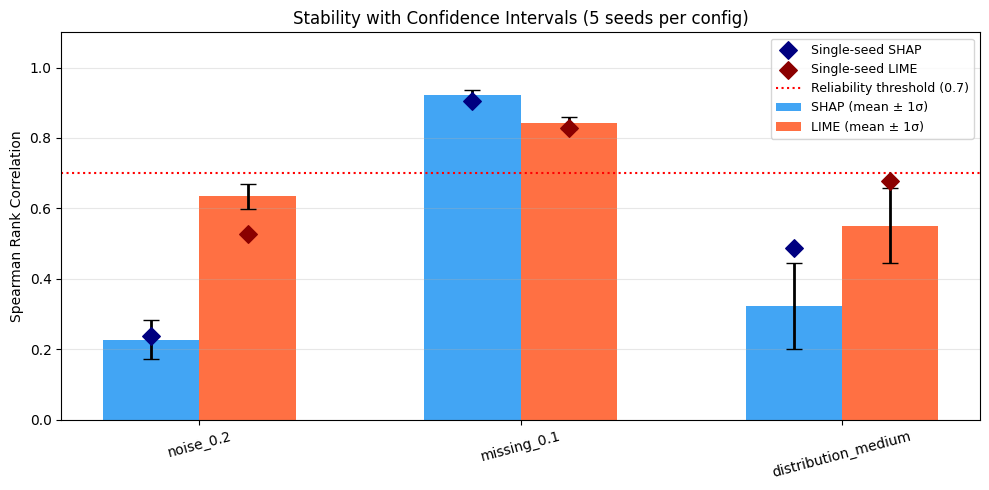


=== Confidence Interval Summary ===


,Config,Drift,Level,SHAP_mean,SHAP_std,LIME_mean,LIME_std
0,noise_0.2,noise,0.2,0.2267,0.0550,0.6337,0.0360
1,missing_0.1,missing,0.1,0.9211,0.0156,0.8428,0.0175
2,distribution_medium,distribution,medium,0.3228,0.1225,0.5509,0.1075


In [15]:
# EXPERIMENT 3: Stability Confidence Intervals (5-seed Monte Carlo)
N_SEEDS = 5
MULTI_SEED_CONFIGS = [
 ("noise", 0.2),
 ("missing", 0.10),
 ("distribution", "medium"),
]

ci_records = []
print("Running multi-seed stability experiments...")

for d_type, d_level in MULTI_SEED_CONFIGS:
 config_key = f"{d_type}_{d_level}"
 shap_spears, lime_spears = [], []

 for trial_seed in range(N_SEEDS):
 seed = 100 + trial_seed
 X_train_drifted = apply_tiered_drift(X_train, d_type, d_level, seed=seed)

 # Retrain XGBoost
 trial_model = build_xgb_model(seed=seed)
 trial_model.fit(
 X_train_drifted, y_train,
 eval_set=[(X_test, y_test)],
 verbose=False
 )

 # SHAP
 np.random.seed(seed)
 trial_shap_exp = shap.KernelExplainer(get_predict_fn(trial_model), background)
 trial_shap_vals_raw = trial_shap_exp.shap_values(base_test_sample, nsamples=100, silent=True)
 trial_shap_mean = np.abs(
 trial_shap_vals_raw[0] if isinstance(trial_shap_vals_raw, list) else trial_shap_vals_raw
 ).mean(axis=0)
 s_sp, _ = calculate_stability_metrics(base_shap_vals, trial_shap_mean)
 shap_spears.append(s_sp)

 # LIME
 trial_lime_exp = LimeTabularExplainer(
 X_train.values, feature_names=X.columns.tolist(),
 class_names=["No Delinquency", "Serious Delinquency"], mode="classification",
 categorical_features=cat_indices, random_state=seed)
 trial_lime_vals = []
 for i in range(len(base_test_sample)):
 exp = trial_lime_exp.explain_instance(
 base_test_sample.iloc[i].values, get_proba_fn(trial_model),
 num_features=len(X.columns), num_samples=300)
 vals = [0.0] * len(X.columns)
 for feat_idx, val in exp.as_map()[1]:
 vals[feat_idx] = abs(val)
 trial_lime_vals.append(vals)
 trial_lime_mean = np.mean(trial_lime_vals, axis=0)
 l_sp, _ = calculate_stability_metrics(base_lime_avg, trial_lime_mean)
 lime_spears.append(l_sp)

 print(f" {config_key} seed={seed}: SHAP_sp={s_sp:.4f} LIME_sp={l_sp:.4f}")

 ci_records.append({
 "Config": config_key,
 "Drift": d_type,
 "Level": str(d_level),
 "SHAP_mean": np.mean(shap_spears),
 "SHAP_std": np.std(shap_spears),
 "LIME_mean": np.mean(lime_spears),
 "LIME_std": np.std(lime_spears),
 })

ci_df = pd.DataFrame(ci_records)

selected_configs = [f"{d}_{l}" for d, l in MULTI_SEED_CONFIGS]
pe_df = results_df[results_df.apply(
 lambda r: f"{r['Drift']}_{r['Level']}" in selected_configs, axis=1
)][["Drift","Level","SHAP_Spearman","LIME_Spearman"]].copy()
pe_df["Config"] = pe_df.apply(lambda r: f"{r['Drift']}_{r['Level']}", axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ci_df))
w = 0.3

bars_shap = ax.bar(x - w/2, ci_df["SHAP_mean"], w,
 yerr=ci_df["SHAP_std"], capsize=6,
 label="SHAP (mean ± 1σ)", color="#2196F3", alpha=0.85, error_kw=dict(linewidth=2))
bars_lime = ax.bar(x + w/2, ci_df["LIME_mean"], w,
 yerr=ci_df["LIME_std"], capsize=6,
 label="LIME (mean ± 1σ)", color="#FF5722", alpha=0.85, error_kw=dict(linewidth=2))

for i, cfg in enumerate(ci_df["Config"]):
 pe_row = pe_df[pe_df["Config"] == cfg]
 if not pe_row.empty:
 ax.scatter(i - w/2, pe_row["SHAP_Spearman"].values[0],
 color="navy", s=80, zorder=10, marker="D", label="Single-seed SHAP" if i==0 else "")
 ax.scatter(i + w/2, pe_row["LIME_Spearman"].values[0],
 color="darkred", s=80, zorder=10, marker="D", label="Single-seed LIME" if i==0 else "")

ax.axhline(0.7, color="red", linestyle=":", linewidth=1.5, label="Reliability threshold (0.7)")
ax.set_xticks(x)
ax.set_xticklabels(ci_df["Config"], rotation=15)
ax.set_ylabel("Spearman Rank Correlation")
ax.set_title(f"Stability with Confidence Intervals ({N_SEEDS} seeds per config)")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\n=== Confidence Interval Summary ===")
display(ci_df.style
 .format({"SHAP_mean":"{:.4f}","SHAP_std":"{:.4f}","LIME_mean":"{:.4f}","LIME_std":"{:.4f}"})
 .background_gradient(cmap="Blues", subset=["SHAP_mean","LIME_mean"]))


### 9.4 Faithfulness via Feature Deletion AUC

The deletion curve test measures model accuracy as top-K SHAP features are progressively masked. A faithful explanation should cause accuracy to drop steeply as the most important features are removed. The area under the deletion curve (AUC) quantifies overall faithfulness — lower AUC = more faithful explanations.

Computing deletion curves...
Baseline Deletion AUC: 0.8866
Worst-drift (distribution_small) Deletion AUC: 0.8865
Faithfulness Drop: 0.02%


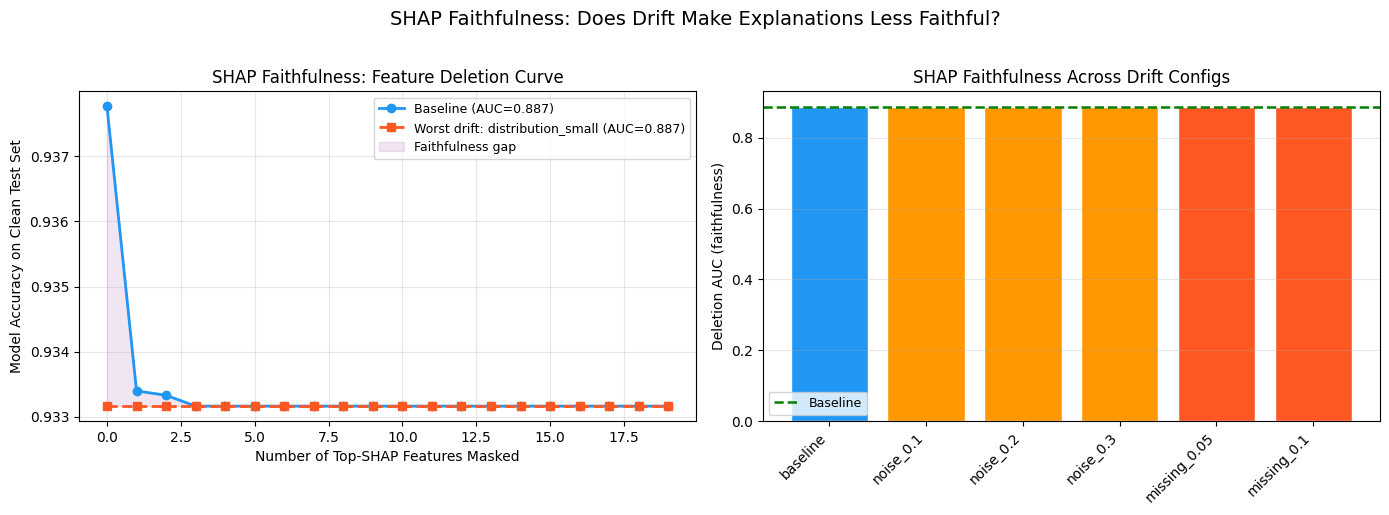

In [16]:
# EXPERIMENT 4: Faithfulness via Feature Deletion AUC

def deletion_curve(model, test_df, shap_importance, feature_names, mask_val=0.0):
 """
 Returns list of (k, accuracy_after_masking_top_k_features).
 mask_val: value to substitute (0.0 = mean-zero for z-scored data).
 """
 n_features = len(feature_names)
 ranked_feats = [feature_names[i] for i in np.argsort(shap_importance)[::-1]]
 # y_test may be a numpy array; convert once for safe indexing
 y_test_arr = y_test if isinstance(y_test, np.ndarray) else np.array(y_test)
 accs = []
 for k in range(0, n_features + 1):
 test_masked = test_df.copy()
 for feat in ranked_feats[:k]:
 if feat in num_cols:
 test_masked[feat] = mask_val
 else:
 test_masked[feat] = cat_modes.get(feat, 0)
 preds = get_predict_fn(model)(test_masked)
 y_pred = (preds >= DECISION_THRESHOLD).astype(int)
 acc = np.mean(y_pred == y_test_arr[:len(test_masked)])
 accs.append((k, acc))
 return accs

test_faithfulness_df = X_test.copy()

print("Computing deletion curves...")

# Baseline curve
baseline_curve = deletion_curve(
 baseline_model, test_faithfulness_df,
 base_shap_vals, list(X.columns))
baseline_accs = [a for _, a in baseline_curve]
baseline_auc = np.trapz(baseline_accs) / len(baseline_accs)

# Worst-drift config (highest SHAP stability loss)
worst_config = results_df.sort_values("SHAP_Loss_%", ascending=False).iloc[0]
worst_key = f"{worst_config['Drift']}_{worst_config['Level']}"
worst_shap_arr = raw_shap_store.get(worst_key)

# Retrain the worst model
worst_run_idx = next(i for i, (d, l) in enumerate(drift_configs)
 if f"{d}_{l}" == worst_key)
worst_seed = GLOBAL_SEED + worst_run_idx
X_train_worst = apply_tiered_drift(
 X_train, worst_config["Drift"], worst_config["Level"], seed=worst_seed)
worst_model = build_xgb_model(seed=worst_seed)
worst_model.fit(X_train_worst, y_train, eval_set=[(X_test, y_test)], verbose=False)

worst_curve = deletion_curve(
 worst_model, test_faithfulness_df,
 worst_shap_arr, list(X.columns))
worst_accs = [a for _, a in worst_curve]
worst_auc = np.trapz(worst_accs) / len(worst_accs)

print(f"Baseline Deletion AUC: {baseline_auc:.4f}")
print(f"Worst-drift ({worst_key}) Deletion AUC: {worst_auc:.4f}")
print(f"Faithfulness Drop: {((baseline_auc - worst_auc)/baseline_auc*100):.2f}%")

ks_vals = list(range(len(baseline_accs)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ks_vals, baseline_accs, "o-", color="#2196F3",
 linewidth=2, label=f"Baseline (AUC={baseline_auc:.3f})")
ax1.plot(ks_vals, worst_accs, "s--", color="#FF5722",
 linewidth=2, label=f"Worst drift: {worst_key} (AUC={worst_auc:.3f})")
ax1.fill_between(ks_vals, baseline_accs, worst_accs,
 alpha=0.1, color="purple", label="Faithfulness gap")
ax1.set_xlabel("Number of Top-SHAP Features Masked")
ax1.set_ylabel("Model Accuracy on Clean Test Set")
ax1.set_title("SHAP Faithfulness: Feature Deletion Curve")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

all_deletion_aucs = {"baseline": baseline_auc}
for config_key, shap_arr in list(raw_shap_store.items())[:5]:
 ri = next((i for i, (d, l) in enumerate(drift_configs)
 if f"{d}_{l}" == config_key), None)
 if ri is not None:
 dseed = GLOBAL_SEED + ri
 d_type_c = drift_configs[ri][0]
 d_level_c = drift_configs[ri][1]
 X_tr_c = apply_tiered_drift(X_train, d_type_c, d_level_c, seed=dseed)
 m_c = build_xgb_model(seed=dseed)
 m_c.fit(X_tr_c, y_train, eval_set=[(X_test, y_test)], verbose=False)
 c_curve = deletion_curve(m_c, test_faithfulness_df, shap_arr, list(X.columns))
 c_accs = [a for _, a in c_curve]
 all_deletion_aucs[config_key] = np.trapz(c_accs) / len(c_accs)

auc_configs = list(all_deletion_aucs.keys())
auc_vals = [all_deletion_aucs[k] for k in auc_configs]
bar_colors2 = ["#2196F3"] + ["#FF9800" if "noise" in k
 else "#9C27B0" if "dist" in k
 else "#FF5722" for k in auc_configs[1:]]
ax2.bar(auc_configs, auc_vals, color=bar_colors2, edgecolor="white")
ax2.axhline(baseline_auc, color="green", linestyle="--", linewidth=1.8, label="Baseline")
ax2.set_ylabel("Deletion AUC (faithfulness)")
ax2.set_title("SHAP Faithfulness Across Drift Configs")
ax2.set_xticklabels(auc_configs, rotation=45, ha="right")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")

plt.suptitle("SHAP Faithfulness: Does Drift Make Explanations Less Faithful?", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
